In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

data_dir = '/path'

## plot method

In [2]:
def plot_boxplot_binary(df, df_melt, tis, state):
    plt.figure(figsize=(10, 8))
#     plt.figure(figsize=(12, 6))

    sns.boxplot(data=df_melt, x='dis', y='binary', hue='metrics',
                palette=["#2f77fc", "#f85151"], width=0.6)

    mean_mcc = df.groupby('dis')['mcc'].mean()
    mean_f1 = df.groupby('dis')['f1'].mean()

    x_positions = range(len(mean_mcc))
    
    offset = 0.15 

    plt.scatter([x - offset for x in x_positions], mean_mcc, 
                color='darkblue', s=100, marker='s', label='Mean MCC', zorder=5)
    plt.scatter([x + offset for x in x_positions], mean_f1, 
                color='darkred', s=100, marker='s', label='Mean F1', zorder=5)

    plt.plot([x - offset for x in x_positions], mean_mcc, color='darkblue', linestyle='--', linewidth=2, alpha=0.7)
    plt.plot([x + offset for x in x_positions], mean_f1, color='darkred', linestyle='--', linewidth=2, alpha=0.7)

    ax = plt.gca()
    dis_vals = sorted(df['dis'].unique())
    ax.set_xticks(range(len(dis_vals)))
    ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])
    
    plt.xlabel('Distance from gene (bp)', fontsize=16)
    plt.ylabel(None)
    plt.title(f'{state} in {tis} (10kb merger)', fontsize=20, pad=20)
    plt.legend(loc='upper right', fontsize=16)
    
    plt.ylim(0, 1.1) 
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    for i, (mcc_mean, f1_mean) in enumerate(zip(mean_mcc, mean_f1)):
        plt.text(i - offset, mcc_mean + 0.02, f'{mcc_mean:.3f}', 
                ha='center', va='bottom', fontsize=14, color='darkblue', fontweight='bold')
        plt.text(i + offset, f1_mean + 0.02, f'{f1_mean:.3f}', 
                ha='center', va='bottom', fontsize=14, color='darkred', fontweight='bold')
    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_tumor/gene_peak_figs/gene_peak_regulation_top_gene_{tis}_{state}_mcc_f1_merge.pdf', format='pdf', dpi=300)
    plt.show()

In [3]:
def plot_scatter_details_binary(df, tis, state):
    fig, ax = plt.subplots(figsize=(16, 10))

    set2_colors = ["#2f77fc", "#f85151"]

    genes = df['gene_name'].unique()
    distances = sorted(df['dis'].unique())
    scatter_data_rotated = []
    for i, gene in enumerate(genes):
        for j, distance in enumerate(distances):
            gene_data = df[(df['gene_name'] == gene) & (df['dis'] == distance)]
            
            if not gene_data.empty:
                mcc_value = gene_data['mcc'].values[0]
                f1_value = gene_data['f1'].values[0]
                
                scatter_data_rotated.append({
                    'x': i,
                    'y': j + 0.2,
                    'size': mcc_value * 2000,
                    'value': mcc_value,
                    'metric': 'MCC',
                    'gene': gene,
                    'distance': distance
                })

                scatter_data_rotated.append({
                    'x': i,
                    'y': j - 0.1, 
                    'size': f1_value * 2000,
                    'value': f1_value,
                    'metric': 'F1',
                    'gene': gene,
                    'distance': distance
                })

    scatter_df_rotated = pd.DataFrame(scatter_data_rotated)

    mcc_df_rotated = scatter_df_rotated[scatter_df_rotated['metric'] == 'MCC']
    f1_df_rotated = scatter_df_rotated[scatter_df_rotated['metric'] == 'F1']

    ax.scatter(mcc_df_rotated['x'], mcc_df_rotated['y'], 
            s=mcc_df_rotated['size'], 
            color=set2_colors[0], alpha=0.8,
            edgecolor=None, linewidth=1,
            label='MCC', zorder=3)
    
    ax.scatter(f1_df_rotated['x'], f1_df_rotated['y'], 
            s=f1_df_rotated['size'], 
            color=set2_colors[1], alpha=0.8,
            edgecolor=None, linewidth=1,
            label='F1', zorder=3)

    for _, row in scatter_df_rotated.iterrows():
        ax.text(row['x'], row['y'], f"{row['value']:.2f}",
                ha='center', va='center',
                color='black', fontsize=16, zorder=4)
        
    for i, gene in enumerate(genes):
        for j, distance in enumerate(distances):
            gene_data = df[(df['gene_name'] == gene) & (df['dis'] == distance)]
            
            if not gene_data.empty:
                total = gene_data['n_total_peaks'].values[0]
                positive = gene_data['n_positive_peaks'].values[0]
                
                info_text = f"{positive} / {total}"
                ax.text(i, j - 0.3, info_text,
                    ha='center', va='top',
                    color='black', fontsize=16,
                    bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='white', alpha=0.7,
                                edgecolor='gray'))

    ax.set_xlim(-0.5, len(genes) - 0.5)
    ax.set_ylim(-0.5, len(distances) - 0.5)
    ax.set_xticks(np.arange(len(genes)))
    ax.set_yticks(np.arange(len(distances)))

    ax.set_xticklabels(genes, fontsize=16)
    ax.set_yticklabels([f'{int(d/1e5)}e5' for d in distances], fontsize=16)

    ax.set_xlabel('Gene', fontsize=16)
    ax.set_ylabel('Distance from gene (bp)', fontsize=16)

    ax.set_title(f'{state} in {tis} (10kb merger)', fontsize=20, pad=20)

    for i in range(len(genes)):
        for j in range(len(distances)):
            if (i + j) % 2 == 0:
                facecolor = '#f5f5f5'
            else:
                facecolor = '#f0f0f0'
                
            rect = plt.Rectangle((i-0.5, j-0.5), 1, 1, 
                                fill=True, alpha=0.3, 
                                edgecolor='lightgray', linewidth=0.5,
                                facecolor=facecolor, zorder=0)
            ax.add_patch(rect)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', 
            label='MCC', markerfacecolor=set2_colors[0], 
            markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', 
            label='F1', markerfacecolor=set2_colors[1], 
            markersize=10, markeredgecolor='black')
    ]

    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=16,
            title='Metric', title_fontsize=16)

    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_tumor/gene_peak_figs/gene_peak_regulation_top_gene_{tis}_{state}_details_mcc_f1_merge.pdf', format='pdf', dpi=300)
    plt.show()

In [4]:
def plot_violin(df, df_melt, tis, state):
    plt.figure(figsize=(14, 8))
    # plt.figure(figsize=(16, 6))

    name_mapping = {
        'epiGen': 'epiGen Perturbation',
        'Random': 'Random'
    }
    df_melt['Method'] = df_melt['Method'].map(name_mapping)

    sns.violinplot(data=df_melt, x='dis', y='AUPR', hue='Method', split=True,
                palette=["#2f77fc", "#f85151"], dodge=True, inner='box', scale='width')

    mean_aupr_epiGen = df.groupby('dis')['epiGen_aupr'].mean()
    mean_aupr_random = df.groupby('dis')['random_aupr'].mean()

    x_positions = range(len(mean_aupr_epiGen))
    plt.scatter([x - 0.1 for x in x_positions], mean_aupr_epiGen, 
                color='darkblue', s=100, marker='s', label='Mean epiGen Perturbation', zorder=5)
    plt.scatter([x + 0.1 for x in x_positions], mean_aupr_random, 
                color='darkred', s=100, marker='s', label='Mean Random', zorder=5)

    plt.plot([x - 0.1 for x in x_positions], mean_aupr_epiGen, color='darkblue', linestyle='--', linewidth=2, alpha=0.7)
    plt.plot([x + 0.1 for x in x_positions], mean_aupr_random, color='darkred', linestyle='--', linewidth=2, alpha=0.7)

    ax = plt.gca()
    dis_vals = sorted(df['dis'].unique())
    ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])
    plt.xlabel('Distance from gene (bp)', fontsize=16)
    plt.ylabel('AUPRC', fontsize=16)
    plt.title(f'{state} in {tis} (10kb merger)', fontsize=20, pad=20)
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=16)
    plt.ylim(0, 1.0)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    for i, (epiGen_mean, random_mean) in enumerate(zip(mean_aupr_epiGen, mean_aupr_random)):
        plt.text(i - 0.1, epiGen_mean + 0.02, f'{epiGen_mean:.3f}', 
                ha='center', va='bottom', fontsize=16, color='darkblue')
        plt.text(i + 0.1, random_mean + 0.02, f'{random_mean:.3f}', 
                ha='center', va='bottom', fontsize=16, color='darkred')

    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_tumor/gene_peak_figs/gene_peak_regulation_top_gene_{tis}_{state}_merge.pdf', format='pdf', dpi=300)
    plt.show()

In [5]:
def plot_scatter_details(df, tis, state):
    fig, ax = plt.subplots(figsize=(18, 10))

    set2_colors = ["#2f77fc", "#f85151"]

    genes = df['gene_name'].unique()
    distances = sorted(df['dis'].unique())
    scatter_data_rotated = []
    for i, gene in enumerate(genes):
        for j, distance in enumerate(distances):
            gene_data = df[(df['gene_name'] == gene) & (df['dis'] == distance)]
            
            if not gene_data.empty:
                epiGen_value = gene_data['epiGen_aupr'].values[0]
                random_value = gene_data['random_aupr'].values[0]
                
                scatter_data_rotated.append({
                    'x': i,
                    'y': j + 0.3,
                    'size': epiGen_value * 2000,
                    'value': epiGen_value,
                    'method': 'epiGen',
                    'gene': gene,
                    'distance': distance
                })
                
                scatter_data_rotated.append({
                    'x': i,
                    'y': j - 0.1, 
                    'size': random_value * 2000,
                    'value': random_value,
                    'method': 'Random',
                    'gene': gene,
                    'distance': distance
                })

    scatter_df_rotated = pd.DataFrame(scatter_data_rotated)

    epiGen_df_rotated = scatter_df_rotated[scatter_df_rotated['method'] == 'epiGen']
    random_df_rotated = scatter_df_rotated[scatter_df_rotated['method'] == 'Random']

    ax.scatter(epiGen_df_rotated['x'], epiGen_df_rotated['y'], 
            s=epiGen_df_rotated['size'], 
            color=set2_colors[0], alpha=0.8,
            edgecolor='black', linewidth=1,
            label='epiGen', zorder=3)
    
    ax.scatter(random_df_rotated['x'], random_df_rotated['y'], 
            s=random_df_rotated['size'], 
            color=set2_colors[1], alpha=0.8,
            edgecolor='black', linewidth=1,
            label='Random', zorder=3)

    for _, row in scatter_df_rotated.iterrows():
        ax.text(row['x'], row['y'], f"{row['value']:.2f}",
                ha='center', va='center',
                color='black', fontsize=16, zorder=4)
        
    for i, gene in enumerate(genes):
        for j, distance in enumerate(distances):
            gene_data = df[(df['gene_name'] == gene) & (df['dis'] == distance)]
            
            if not gene_data.empty:
                total = gene_data['n_total_peaks'].values[0]
                positive = gene_data['n_positive_peaks'].values[0]
                
                info_text = f"{positive} / {total}"
                ax.text(i, j - 0.3, info_text,
                    ha='center', va='top',
                    color='black', fontsize=16,
                    bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='white', alpha=0.7,
                                edgecolor='gray'))

    ax.set_xlim(-0.5, len(genes) - 0.5)
    ax.set_ylim(-0.5, len(distances) - 0.5)
    ax.set_xticks(np.arange(len(genes)))
    ax.set_yticks(np.arange(len(distances)))

    ax.set_xticklabels(genes, fontsize=16)
    ax.set_yticklabels([f'{int(d/1e5)}e5' for d in distances], fontsize=16)

    ax.set_xlabel('Gene', fontsize=16)
    ax.set_ylabel('Distance from gene (bp)', fontsize=16)

    ax.set_title(f'AUPRC for {state} in {tis} (10kb merger)', fontsize=20, pad=20)

    for i in range(len(genes)):
        for j in range(len(distances)):
            if (i + j) % 2 == 0:
                facecolor = '#f5f5f5'
            else:
                facecolor = '#f0f0f0'
                
            rect = plt.Rectangle((i-0.5, j-0.5), 1, 1, 
                                fill=True, alpha=0.3, 
                                edgecolor='lightgray', linewidth=0.5,
                                facecolor=facecolor, zorder=0)
            ax.add_patch(rect)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', 
            label='epiGen Perturbation', markerfacecolor=set2_colors[0], 
            markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', 
            label='Random', markerfacecolor=set2_colors[1], 
            markersize=10, markeredgecolor='black')
    ]

    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=16,
            title='Method', title_fontsize=16)

    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_tumor/gene_peak_figs/gene_peak_regulation_top_gene_{tis}_{state}_details_merge.pdf', format='pdf', dpi=300)
    plt.show()

In [6]:
# 'pancreas', 'uterus', 'colon', 'breast', 'skin', 'tongue'

## tumor

In [7]:
tis = 'pancreas'

/tmp/ipykernel_1286675/1612455011.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df_melt, x='dis', y='AUPR', hue='Method', split=True,
/tmp/ipykernel_1286675/1612455011.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])


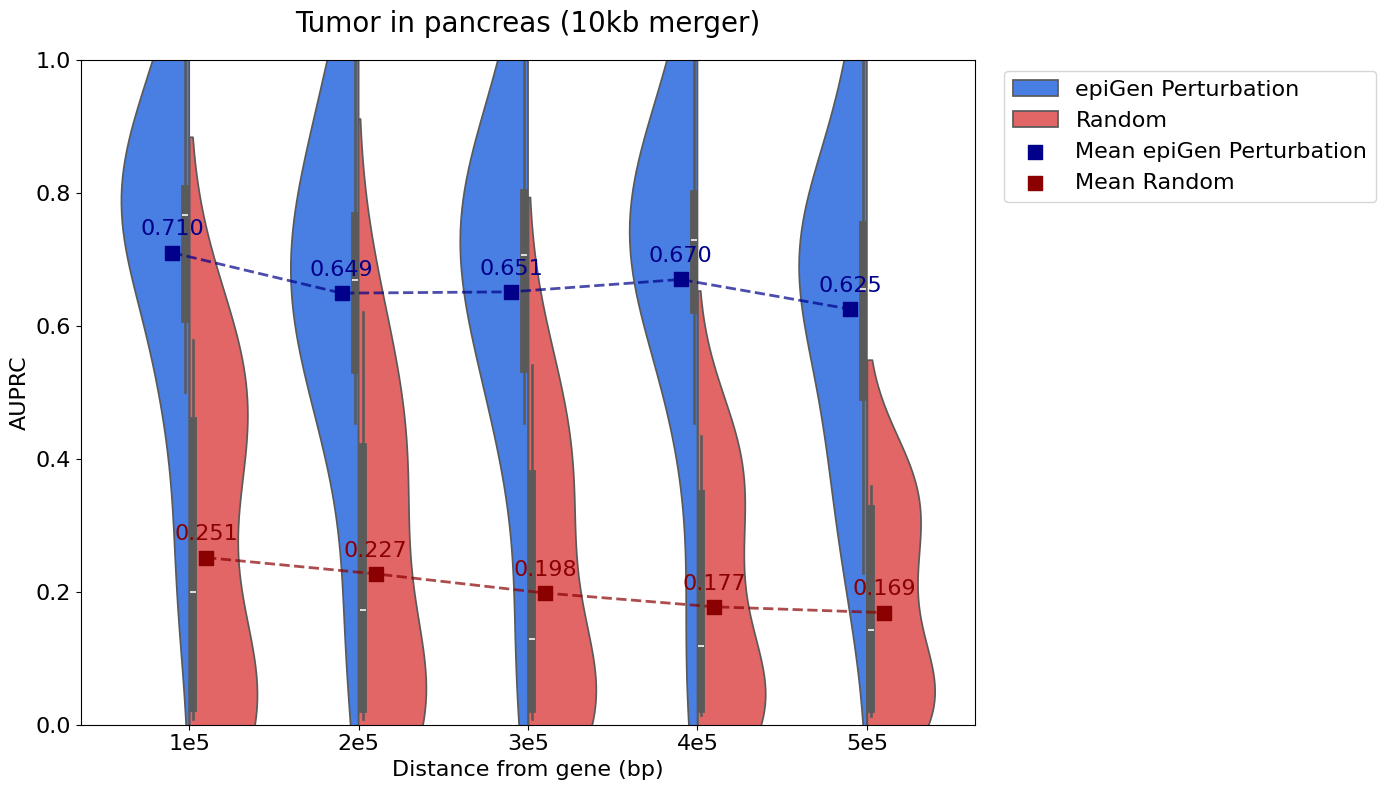

In [8]:
state = 'Tumor'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000.csv", index_col=0).iloc[:, :9]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['epiGen_aupr', 'random_aupr'],
                  var_name='Method',
                  value_name='AUPR')

df_melt['Method'] = df_melt['Method'].map({
    'epiGen_aupr': 'epiGen',
    'random_aupr': 'Random'
})

# df['dis_str'] = df['dis'].astype(int).apply(lambda x: f"{x//1000}kb")
# df_melt['dis_str'] = df_melt['dis'].astype(int).apply(lambda x: f"{x//1000}kb")
plot_violin(df, df_melt, tis, state)

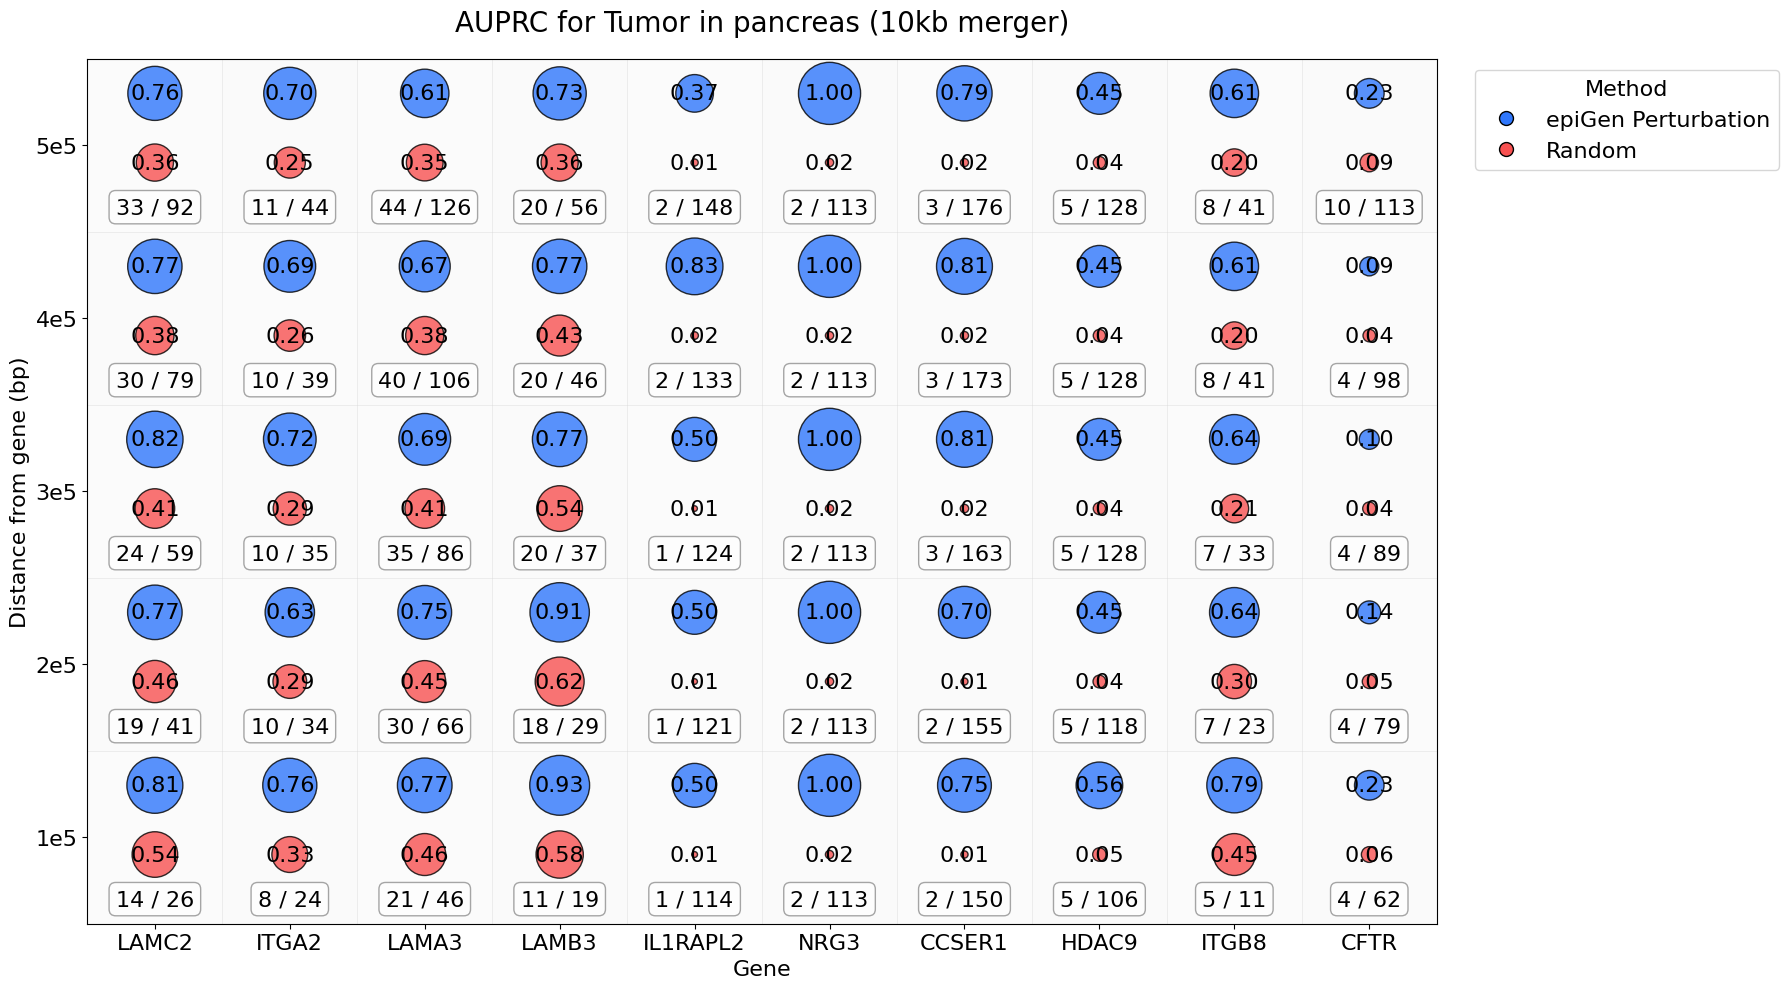

In [9]:
plot_scatter_details(df, tis, state)

## tumor binary

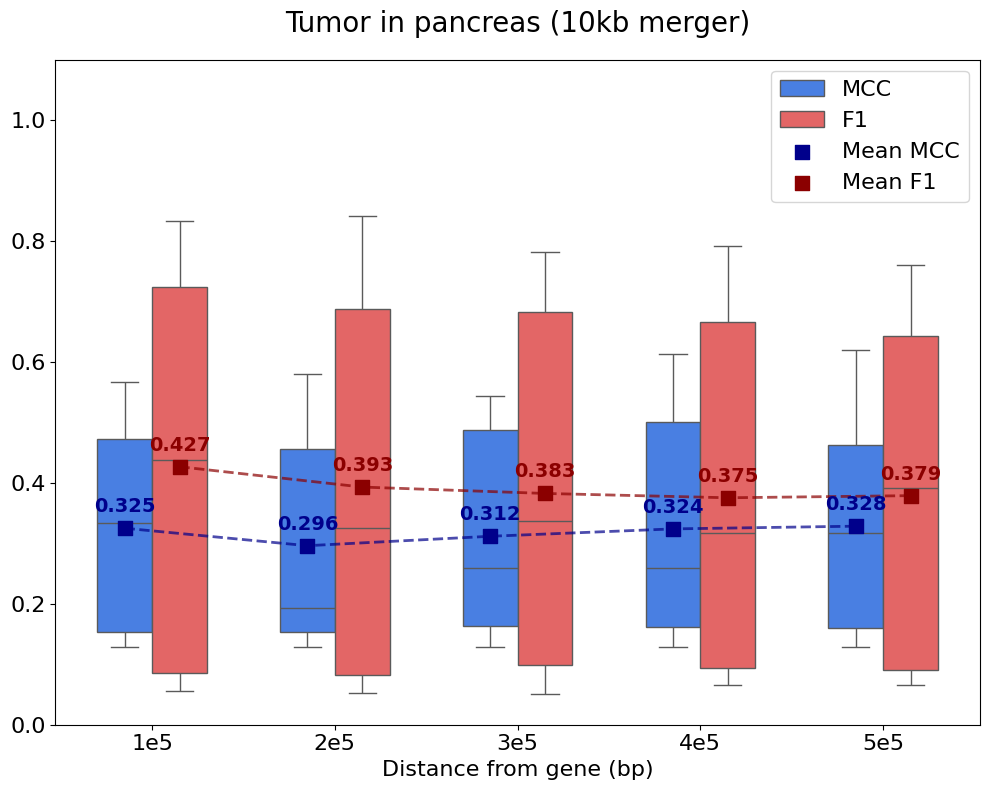

In [10]:
state = 'Tumor'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000.csv", index_col=0).iloc[:, :9]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['mcc', 'f1'],
                  var_name='metrics',
                  value_name='binary')
df_melt['metrics'] = df_melt['metrics'].map({
    'mcc': 'MCC',
    'f1': 'F1'
})

# df['dis_str'] = df['dis'].astype(int).apply(lambda x: f"{x//1000}kb")
# df_melt['dis_str'] = df_melt['dis'].astype(int).apply(lambda x: f"{x//1000}kb")

plot_boxplot_binary(df, df_melt, tis, state)

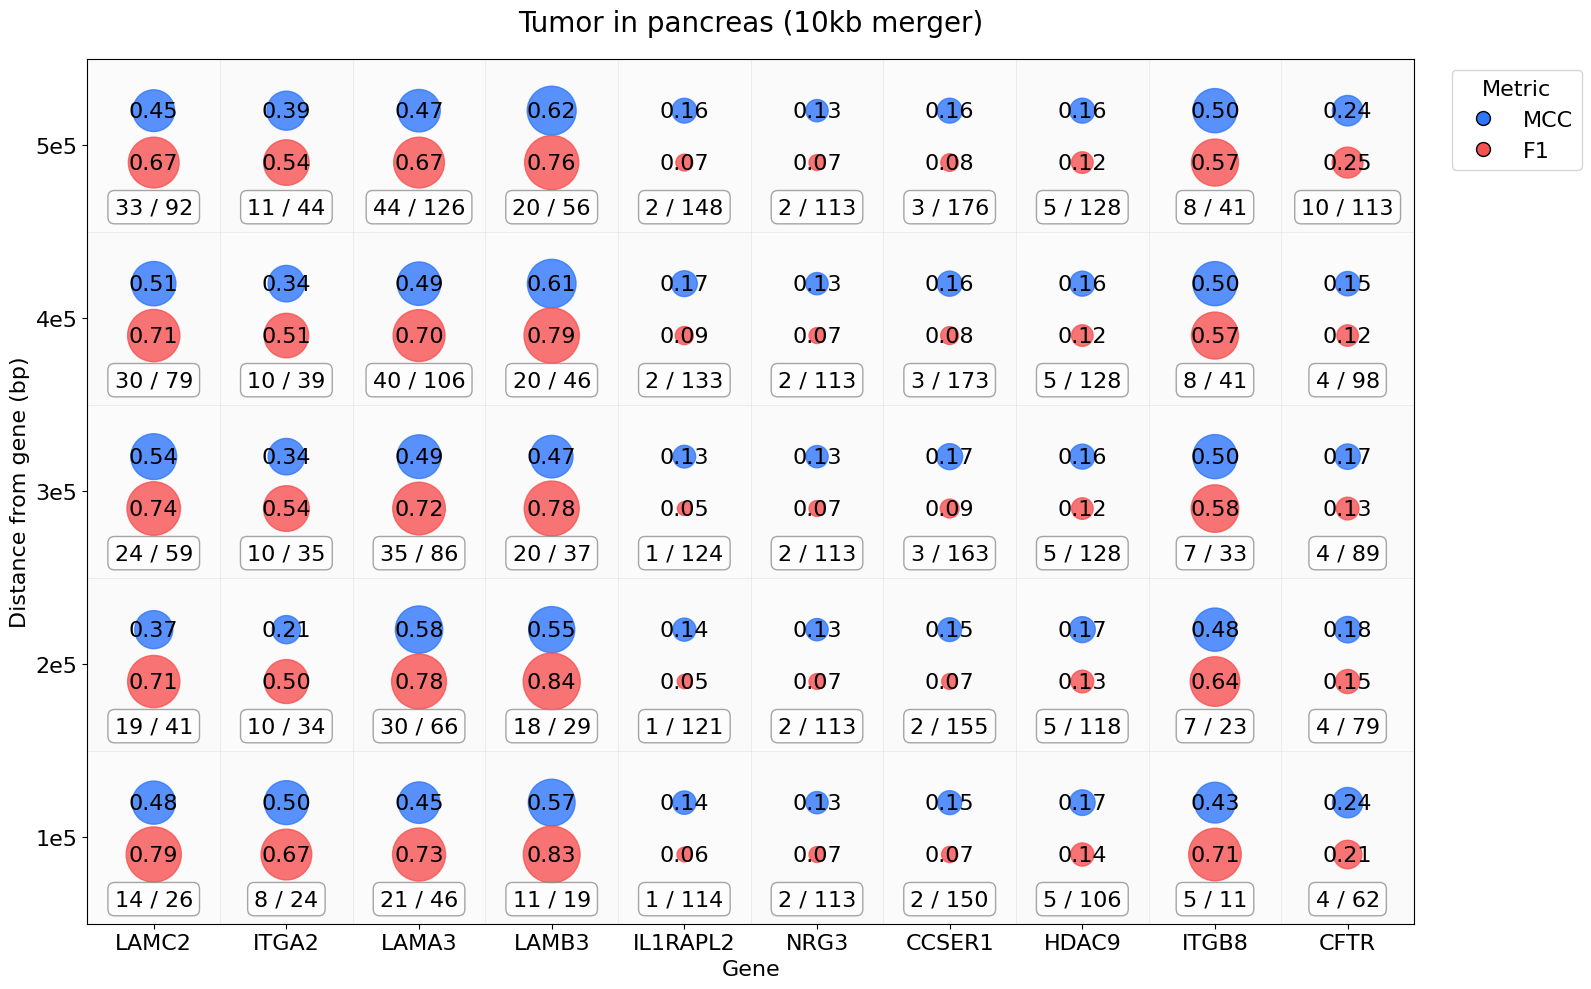

In [11]:
plot_scatter_details_binary(df, tis, state)

## normal

/tmp/ipykernel_1286675/1612455011.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df_melt, x='dis', y='AUPR', hue='Method', split=True,
/tmp/ipykernel_1286675/1612455011.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])


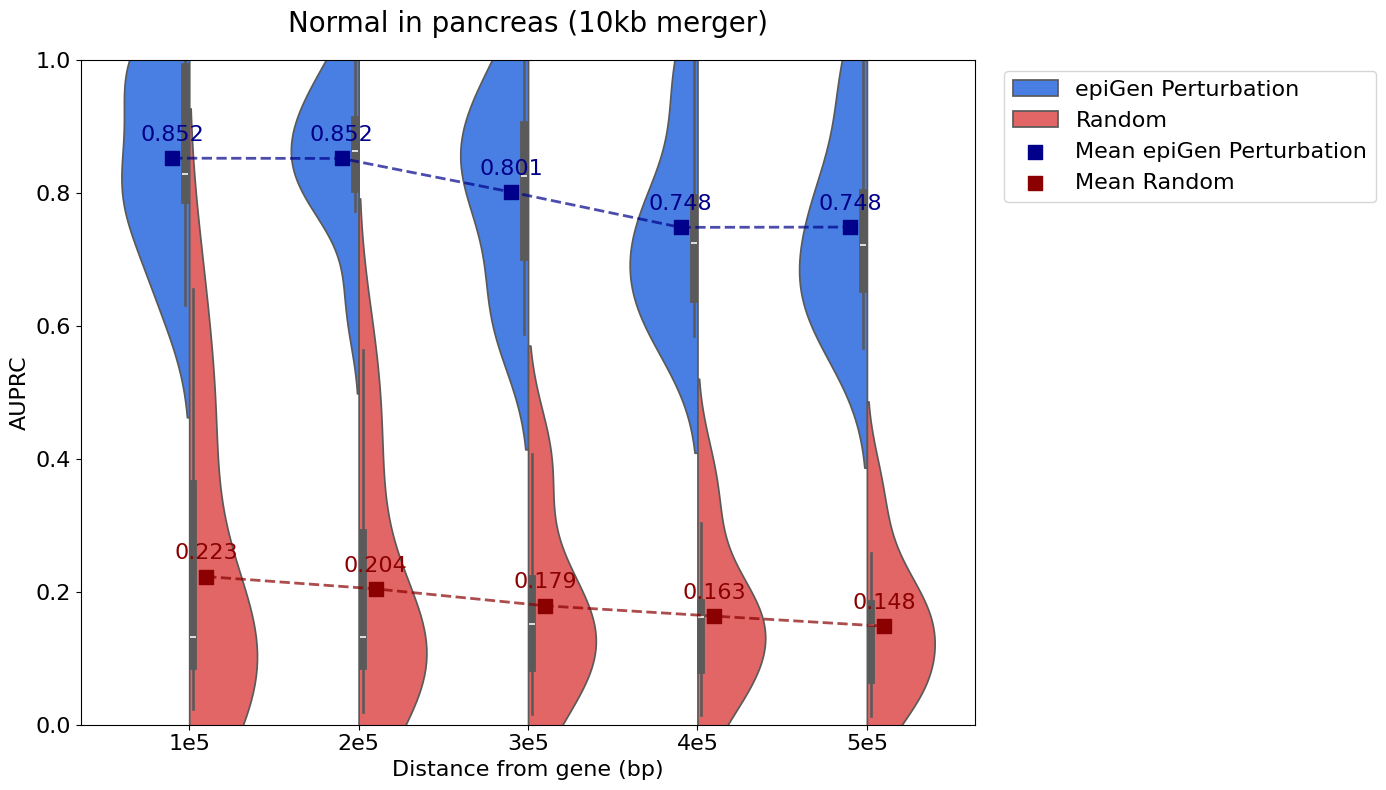

In [12]:
state = 'Normal'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000.csv", index_col=0).iloc[:, :9]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['epiGen_aupr', 'random_aupr'],
                  var_name='Method',
                  value_name='AUPR')

df_melt['Method'] = df_melt['Method'].map({
    'epiGen_aupr': 'epiGen',
    'random_aupr': 'Random'
})

# df['dis_str'] = df['dis'].astype(int).apply(lambda x: f"{x//1000}kb")
# df_melt['dis_str'] = df_melt['dis'].astype(int).apply(lambda x: f"{x//1000}kb")
plot_violin(df, df_melt, tis, state)

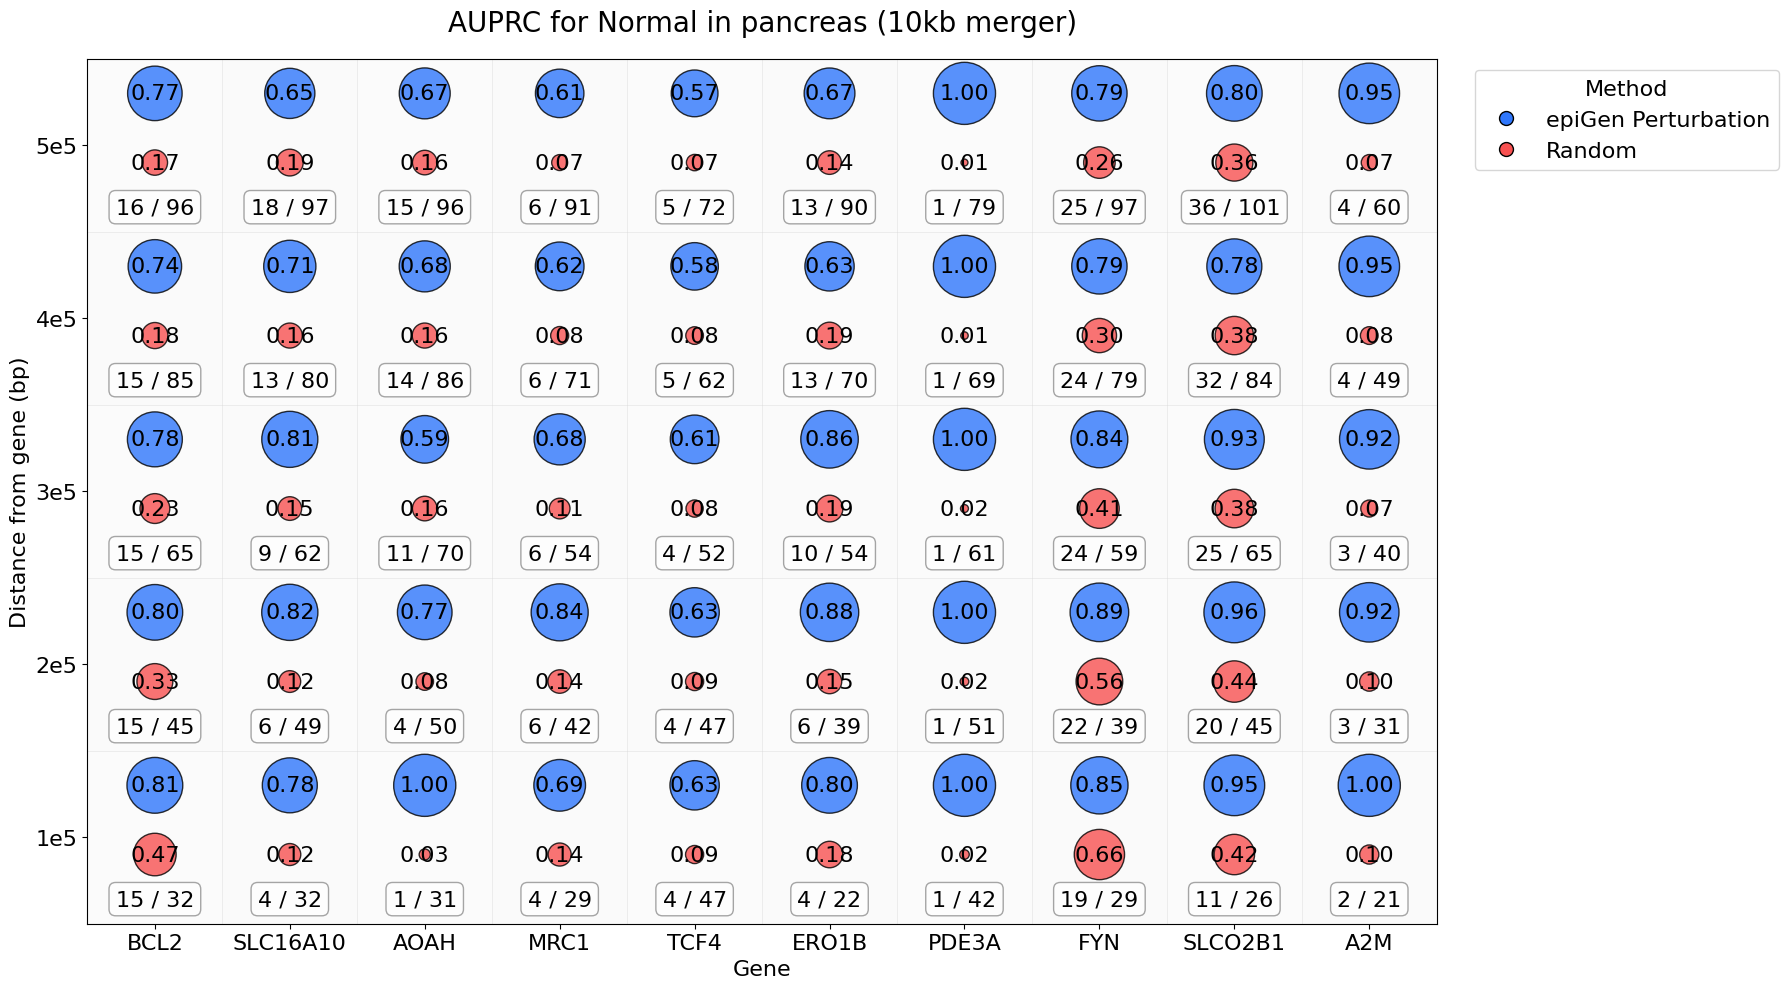

In [13]:
plot_scatter_details(df, tis, state)

## normal binary

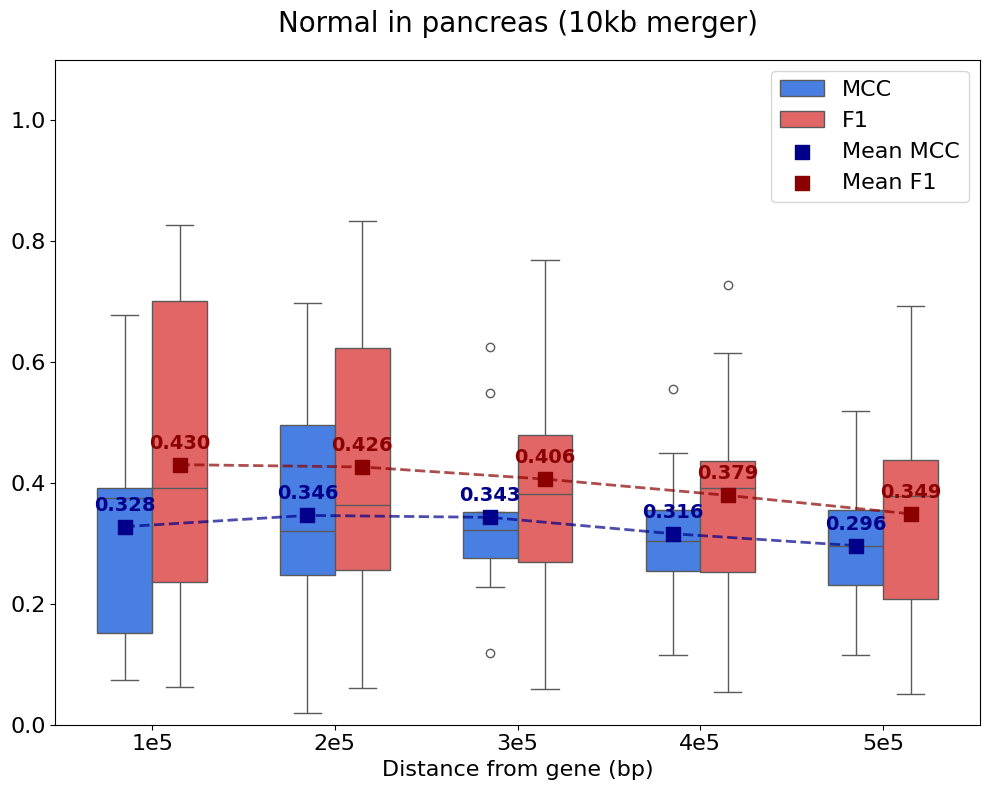

In [14]:
state = 'Normal'
df = pd.read_csv(data_dir + f"/perturbation_tumor/gene_peak_nearby_merge/{tis}_nearby_aupr_{state}_permutation_10000.csv", index_col=0).iloc[:, :9]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['mcc', 'f1'],
                  var_name='metrics',
                  value_name='binary')
df_melt['metrics'] = df_melt['metrics'].map({
    'mcc': 'MCC',
    'f1': 'F1'
})

# df['dis_str'] = df['dis'].astype(int).apply(lambda x: f"{x//1000}kb")
# df_melt['dis_str'] = df_melt['dis'].astype(int).apply(lambda x: f"{x//1000}kb")

plot_boxplot_binary(df, df_melt, tis, state)

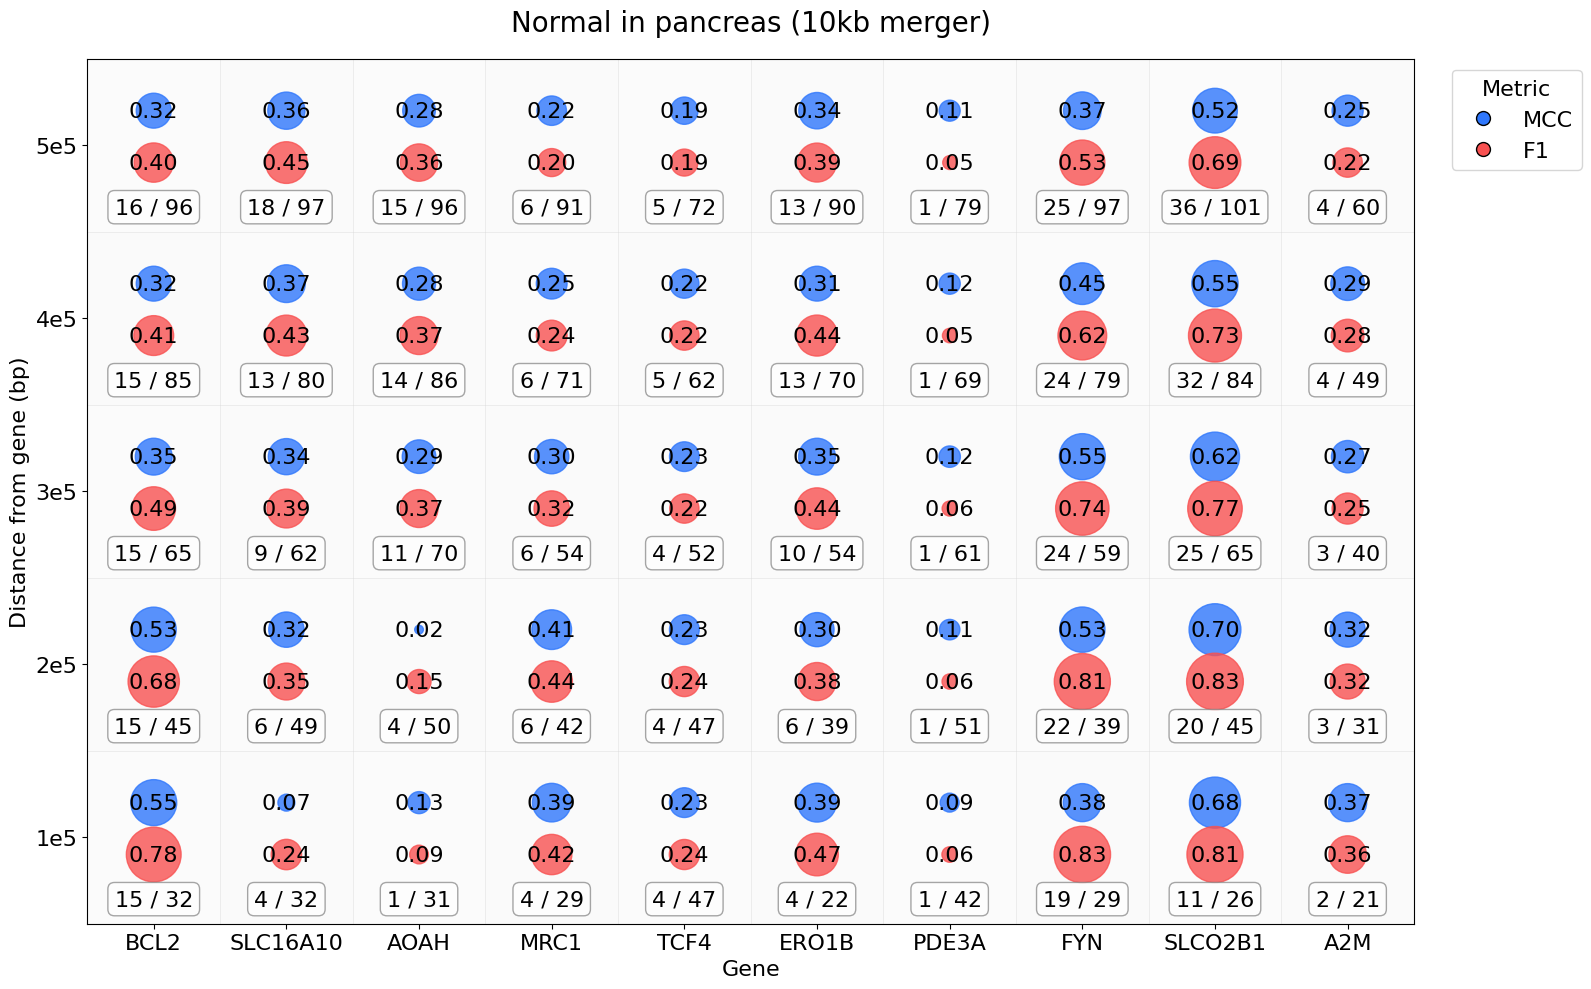

In [15]:
plot_scatter_details_binary(df, tis, state)